In [10]:
import sys
import os

sys.path.append(os.path.abspath('../..'))

from technical_func import set_random_seed
from swiss_roll_geometry import get_manual_2d_spiral, visualize_learned_manifold
from model_autoencoder import AutoencoderSimple
from train_model import fit_model, get_data_loader
from data_file import TensorIndexDataset
import matplotlib.pyplot as plt


device = "cuda:0"

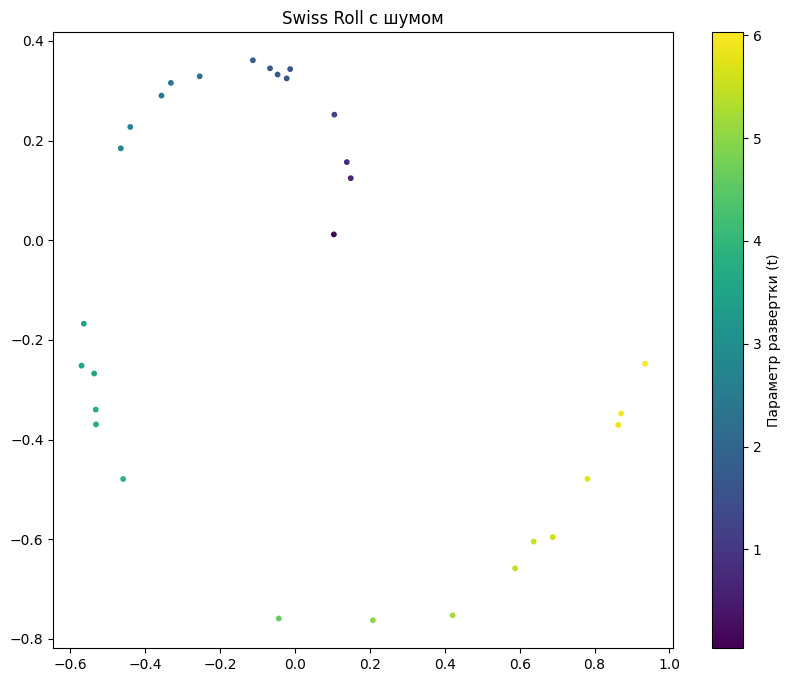

In [11]:
set_random_seed(42)

data_noisy, colors = get_manual_2d_spiral(n_samples=30, noise=0.01)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
sc = ax.scatter(data_noisy[:, 0], data_noisy[:, 1],  c=colors, cmap='viridis', s=10)
ax.set_title("Swiss Roll с шумом")
plt.colorbar(sc, label='Параметр развертки (t)')
plt.show()


In [12]:
if __name__ ==  "__main__":
    batch_size = 30
    dataset = TensorIndexDataset(data_noisy, data_noisy.clone(), colors)
    train_loader = get_data_loader(batch_size, dataset)


c:\Users\sergey\Documents\crs_lock\data_file.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.colors = torch.tensor(colors, dtype=torch.float32)


In [13]:
data_clear, c = get_manual_2d_spiral(n_samples=1000, noise=0.00)


In [14]:
set_random_seed(42)

student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher.load_state_dict(student.state_dict())
    
student, teacher, _, _ = fit_model(student, teacher, train_loader, epochs=2000, reg_mode="none", verbose_latent=False)

Train metrics: {'loss': 0.20121228694915771, 'rec_loss': 0.20121228694915771, 'enc_loss': 0.0, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.01088358461856842, 'rec_loss': 0.01088358461856842, 'enc_loss': 0.0, 'dec_loss': 0.0} cur epoch: 1000
Train metrics: {'loss': 0.0010799969313666224, 'rec_loss': 0.0010799969313666224, 'enc_loss': 0.0, 'dec_loss': 0.0} cur epoch: 1999


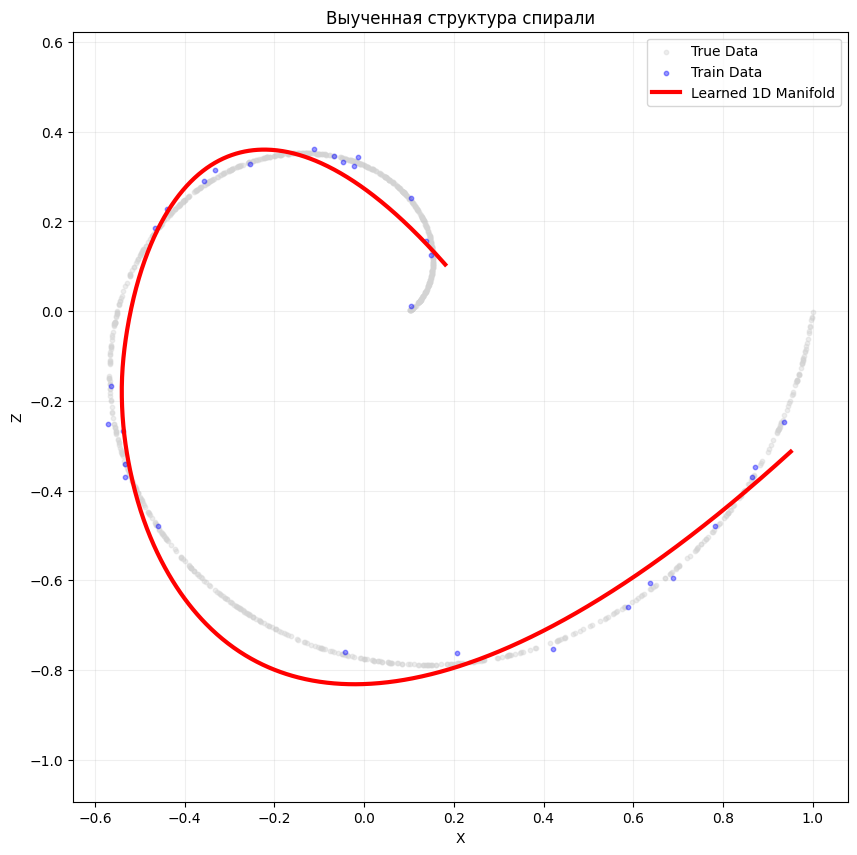

In [15]:
visualize_learned_manifold(student, data_clear, data_noisy)


In [46]:
set_random_seed(42)

student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher.load_state_dict(student.state_dict())
    
student, teacher, _, _ = fit_model(student, teacher, train_loader, epochs=2000, reg_mode="encoder", n_points=2, radius_encoder=0.1, lambda_enc=1e0, verbose_latent=False, teacher_momentum=0.5)

Train metrics: {'loss': 0.20121228694915771, 'rec_loss': 0.20121228694915771, 'enc_loss': 4.877118153778781e-10, 'dec_loss': 0.0} cur epoch: 0
Train metrics: {'loss': 0.001868543098680675, 'rec_loss': 0.0018677872139960527, 'enc_loss': 7.558405172858329e-07, 'dec_loss': 0.0} cur epoch: 1000
Train metrics: {'loss': 0.0007162737310864031, 'rec_loss': 0.0007150354795157909, 'enc_loss': 1.2382370186969638e-06, 'dec_loss': 0.0} cur epoch: 1999


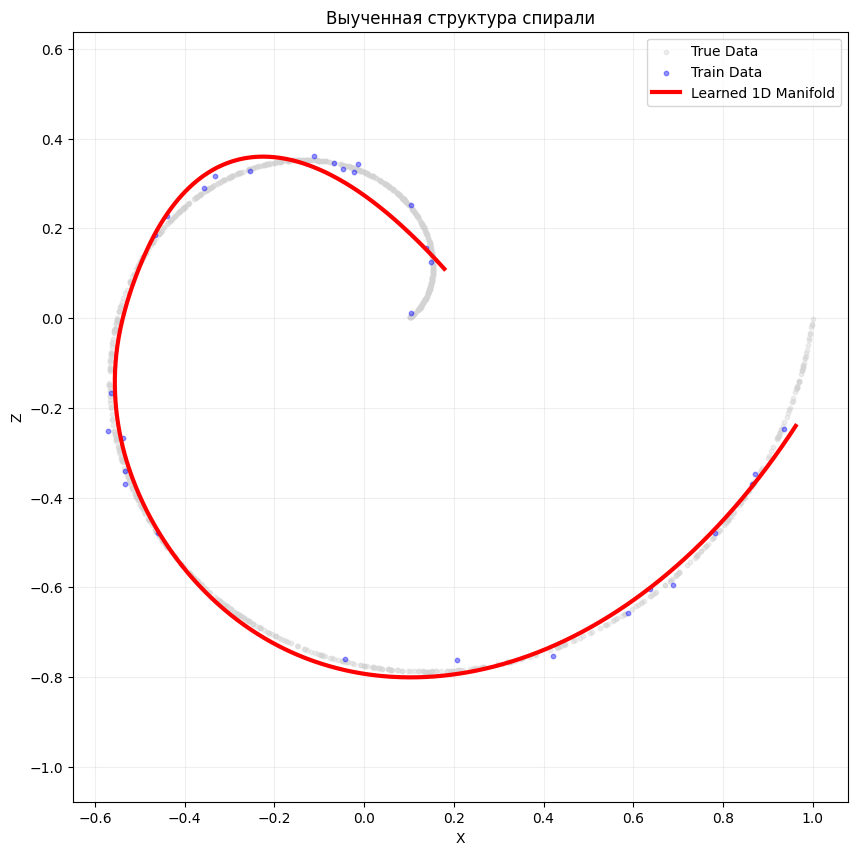

In [47]:
visualize_learned_manifold(student, data_clear, data_noisy)



In [26]:
set_random_seed(42)
student = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher = AutoencoderSimple(2, 2, 1, activation="elu").to(device)
teacher.load_state_dict(student.state_dict())
    
student, teacher, _, _ = fit_model(student, teacher, train_loader, epochs=2000, reg_mode="decoder", n_points=2, radius_decoder=0.01, lambda_dec=0.01, teacher_momentum=0.99, verbose_latent=False)

Train metrics: {'loss': 0.20122158527374268, 'rec_loss': 0.20121228694915771, 'enc_loss': 0.0, 'dec_loss': 0.18606513738632202} cur epoch: 0
Train metrics: {'loss': 0.0017825003014877439, 'rec_loss': 0.0017377305775880814, 'enc_loss': 0.0, 'dec_loss': 0.004476973321288824} cur epoch: 1000
Train metrics: {'loss': 0.0006157839670777321, 'rec_loss': 0.0006096175638958812, 'enc_loss': 0.0, 'dec_loss': 0.00061663897940889} cur epoch: 1999


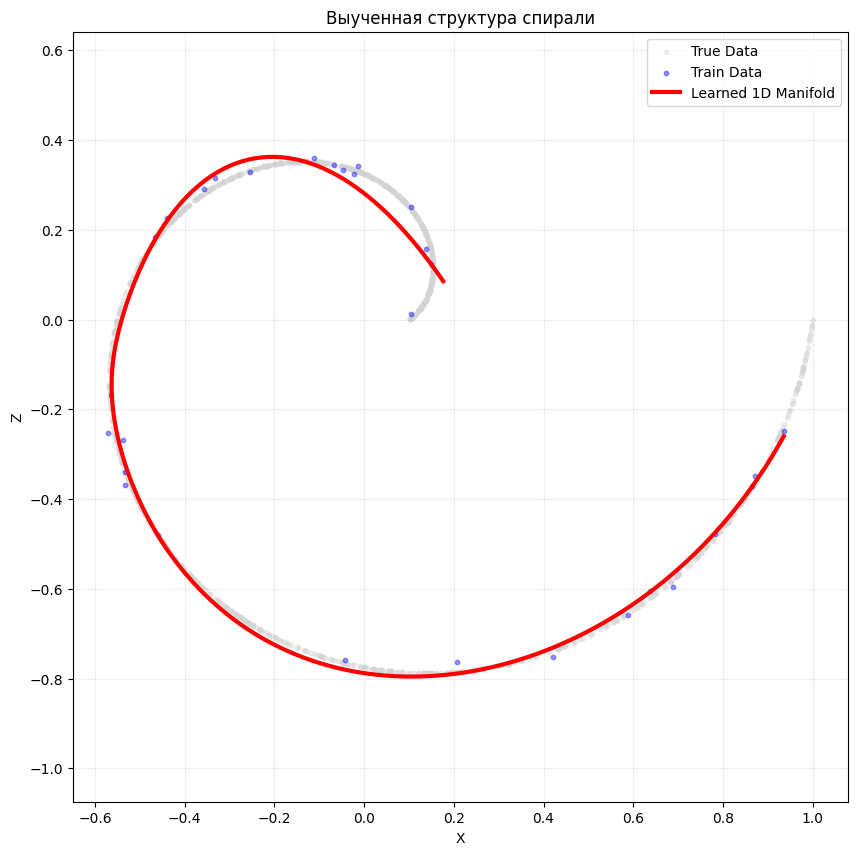

In [27]:
visualize_learned_manifold(student, data_clear, data_noisy)

